In [1]:
import os
import sys

# python_dir = os.path.join(os.getcwd(), "python")
# if python_dir not in sys.path:
#     sys.path.insert(0, python_dir)

from wealth_process_V_opt import *
from optim import *
from decimal import *
import pandas as pd
import warnings
import time
import seaborn as sns

# Mean Variance trade-off under ruin consideration

The wealth of a miner is provided by 

$$
X_t = x - c\cdot t + b\cdot N_t, \quad t\geq0,  
$$

when solo mining. 

The mean and variance, over some time horizon $t$ are given by 

$$
\mathbb{E}(X_t) = x - ct +b\lambda t\text{, and } \mathbb{V}(X_t) = b^2\lambda t
$$

The mean and variance, over some time horizon $T\sim\text{Exp}(1/t)$, provided that ruin does not occur, are given by 

$$
V_1(x,t) = \mathbb{E}(X_T\mathbb{I}_{\tau >T}) =  x + \left[\lambda b - c\right]t(1-e^{\rho^\ast x})\text{, and } V_2(x,t) = \mathbb{E}(X_T^2\mathbb{I}_{\tau >T}) = t\left(\lambda b^2 + 2t(\lambda b - c)^2\right)(1-e^{\rho^\ast x})+ x^2 + 2t(\lambda b -c)x 
$$
Therefore we have 

$$
\mathbb{V}(X_T\mathbb{I}_{\tau >T}) = V_2(x,t) - V_1^2(x,t)
$$

where $T\sim\text{Exp}(1/t)$ and $\tau = \inf\{t\geq 0| X_t \geq 0\}$, and $\rho^\ast$ is the only negative solution to the equation

$$
-c\rho + \lambda (e^{\rho b}-1)  = 1/t.
$$

The solution is given in terms of the Lambdert W function with

$$
\rho^\ast = -\frac{\lambda t + 1}{ct} - W\left(-\frac{\lambda  b}{c}e^{-\frac{\lambda t + 1}{ct}b}\right) / b
$$

We note that $V_1(x,t)\rightarrow x - ct + b\lambda t $ but $ \mathbb{V}(X_T\mathbb{I}_{\tau >T}) \rightarrow \mathbb{V}(X_T) \neq \mathbb{V}(X_t)$ when $x\rightarrow \infty$

In [6]:
lam ,b = 6, 3.125 # block discovery rate of the network and reward for finding a block
# Rate of discovery by the network is 6 blocks per hour and the block finding reward is 3.125
c = lam * b / 1.3  # operational cost per time unit (profitability on average)
x = 10  # initial wealth of the miner
t = 1  # time horizon for the wealth process
X_solo = wealth_process(lam, b, c, 0, 1) # Define the wealth process for a solo miner
# Compute the expected value of the wealth process at time T=1
X_solo.E(x), X_solo.Var()
V1, V2 = X_solo.E_Var_no_ruin(x, t)
V1, np.sqrt(V2 - V1**2)

(np.float64(14.186557453835489), np.float64(8.843236895385385))

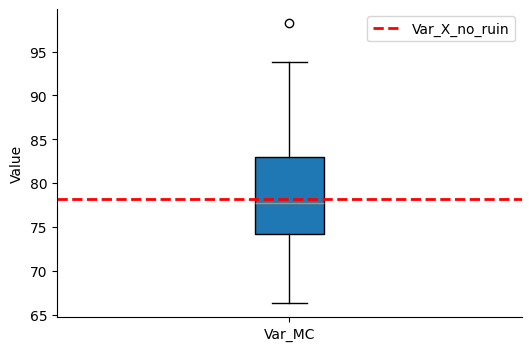

(np.float64(14.148975446231459), np.float64(78.51718218380444))

In [10]:
V1_MC, Var_MC = [], []
for _ in range(100):
    V1_obs = []
    
    for _ in range(1000):
        t_exp = np.random.exponential(t, size=1)[0]
        X_solo.sample(t_exp)
        traj = X_solo.Xt(x)
        Ti_minus = np.append(X_solo.data["Ti"][1:]-1e-6, t_exp)
        if np.any(np.array([traj(t) for t in Ti_minus]) < 0):
            V1_obs.append(0)
        else:
            V1_obs.append(traj(t_exp))
    V1_obs = np.array(V1_obs)            
    V1_MC.append(np.mean(V1_obs)), Var_MC.append(np.var(V1_obs))
plt.figure(figsize=(6, 4))
plt.boxplot(Var_MC, vert=True, patch_artist=True)
plt.axhline(y=V2 - V1**2, color='red', linestyle='--', linewidth=2, label='Var_X_no_ruin')
plt.ylabel('Value')
plt.xticks([1], ['Var_MC'])
plt.legend()
sns.despine()
plt.show()
np.array(V1_MC).mean(), np.array(Var_MC).mean()

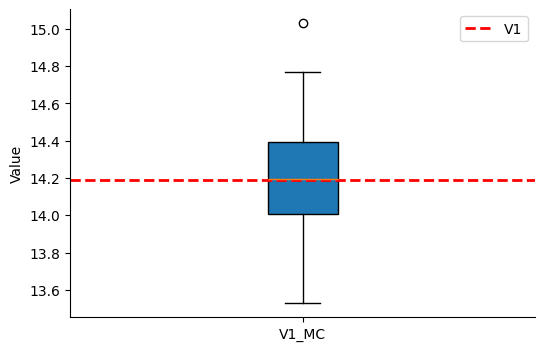

In [8]:
plt.figure(figsize=(6, 4))
plt.boxplot(V1_MC, vert=True, patch_artist=True)
plt.axhline(y=V1, color='red', linestyle='--', linewidth=2, label='V1')
plt.ylabel('Value')
plt.xticks([1], ['V1_MC'])
plt.legend()
sns.despine()
plt.show()

The miner can mitigate the risk by mining for a pool instead of mining solo. Say, there are $n$ mining pools offering a rate of share discoveries $\lambda_k$ and a reward $b_k$ for $k = 1,\ldots, n$, such that 

$$\lambda_0 < \lambda_1 <\ldots < \lambda_n\text{ and }b_0>b_1>\ldots >b_n,$$

where $\lambda_0$ and $b_0$ correspond to the characteristics of solo mining. We can caracterize the reward and arrival rate of the pools by defining a pool fee $f_k$ and difficulty reduction $\delta_k$ for $k = 1,\ldots, n$. 

## Example 3

In [13]:
f0, f1, f2, f3 =0, 0.005, 0.01, 0.1  # pool fees
delta0, delta1, delta2, delta3 = 1, 0.99, 0.85, 0.75  # difficulty reduction
deltas = np.array([delta0, delta1, delta2, delta3])
fs = np.array([f0, f1, f2, f3])  # pool fees
lams= lam / deltas # arrival rates of the pools
bs = b * (1 - fs) * deltas  # rewards after pool fees
X_pools = [wealth_process(lam, b, c, 0, 1 ) for lam, b in zip(lams, bs)]
# Compute the expected values and variance of the wealth process at time T=1 for each pool
E_pools = [X.E(x) for X in X_pools]
Var_pools = [X.Var() for X in X_pools]
V1_V2_pools = [X.E_Var_no_ruin(x, t) for X in X_pools]
np.array([V1_V2_pool[0] for V1_V2_pool in V1_V2_pools]), np.sqrt(np.array([V1_V2_pool[1] - V1_V2_pool[0]**2 for V1_V2_pool in V1_V2_pools]))

(array([14.18655745, 14.09693902, 14.04426356, 12.39111518]),
 array([8.8432369 , 8.72965326, 8.16825423, 6.47590255]))

The miner can split her resources  accross the pools, the wealth process then is given by 

$$
X_t = x -c\cdot t + \sum_{i = 1}^{N_t}B_i,
$$

which allows the miner to adjust her mean and variance trade-off. The split is characterized by a weight vector $w = \left(\begin{array}{ccc}w_0 &\cdots& w_{n}\end{array}\right)$.

The mean and variance of the process are given by

$$
\mathbb{E}(X_t) = x -ct + \mu t\sum_{k=0}^np_kb_k\text{ and }\mathbb{V}(X_t) = \mu t\sum_{k=0}^np_kb_k^2 
$$

The mean and variance provided that ruin did not ocur are given by 

$$
V_1(x,t) = \mathbb{E}(X_T\mathbb{I}_{\tau >T}) =  x + \left[\mu \mathbb{E}(B) - c\right]t(1-e^{\rho^\ast x})\text{, and } V_2(x,t) = \mathbb{E}(X_T^2\mathbb{I}_{\tau >T}) = t\left(\mu \mathbb{E}(B^2) + 2t(\mu \mathbb{E}(B) - c)^2\right)(1-e^{\rho^\ast x})+ x^2 + 2t(\mu \mathbb{E}(B) -c)x 
$$

where $\rho^\ast$ is the unique negative solution to the equation

$$
-c\rho + \mu \left(\mathbb{E}(e^{\rho B})-1\right)  = 1/t.
$$

In [18]:
np.random.seed(42) # Fix the random seed for reproducibility
n = 4 # specify the number of pools
alpha = np.ones(n)  # parameter of the Dirichlet distribution
w = np.random.dirichlet(alpha)
print(f"Weight vector w = {w}")
X_mixed = wealth_process(lams, bs, c, n, w)
X_mixed.E(x), X_mixed.Var()
V1, V2 = X_mixed.E_Var_no_ruin(x, t)
print(V1, V2 - V1**2)

Weight vector w = [0.08219683 0.52725178 0.2306407  0.15991069]
13.820912203242157 68.28172208347922


In [22]:
V1_MC, Var_MC = [], []
for _ in range(100):
    V1_obs = []
    
    for _ in range(1000):
        t_exp = np.random.exponential(t, size=1)[0]
        X_mixed.sample(t_exp)
        traj = X_mixed.Xt(x)
        Ti_minus = np.append(X_mixed.data["Ti"][1:]-1e-6, t_exp)
        if np.any(np.array([traj(t) for t in Ti_minus]) < 0):
            V1_obs.append(0)
        else:
            V1_obs.append(traj(t_exp))
    V1_obs = np.array(V1_obs)            
    V1_MC.append(np.mean(V1_obs)), Var_MC.append(np.var(V1_obs))

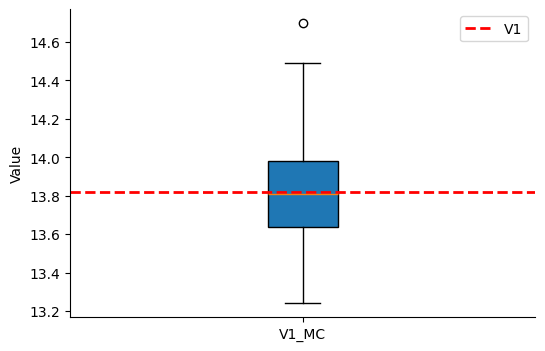

(np.float64(13.804106286637625), np.float64(68.75336679584592))

In [20]:
plt.figure(figsize=(6, 4))
plt.boxplot(V1_MC, vert=True, patch_artist=True)
plt.axhline(y=V1, color='red', linestyle='--', linewidth=2, label='V1')
plt.ylabel('Value')
plt.xticks([1], ['V1_MC'])
plt.legend()
sns.despine()
plt.show()
np.array(V1_MC).mean(), np.array(V2_MC).mean()

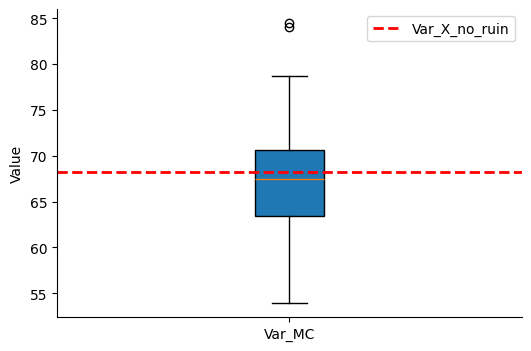

In [23]:
plt.figure(figsize=(6, 4))
plt.boxplot(Var_MC, vert=True, patch_artist=True)
plt.axhline(y=V2 - V1**2, color='red', linestyle='--', linewidth=2, label='Var_X_no_ruin')
plt.ylabel('Value')
plt.xticks([1], ['Var_MC'])
plt.legend()
sns.despine()
plt.show()

The goal is now to find the computing power distribution that achieve a good mean variance trade-off!

## Risk aversion parameter and mean-variance trade off

Assume that the miner is characterized by a risk aversion parameter $\gamma$ and wishes to optimize the following criteria

$$
V(w) = \mathbb{E}(X_T\mathbb{I}_{\tau > T}) - \gamma \mathbb{V}(X_T \mathbb{I}_{\tau > T}).
$$

It can be done numerically. Let us start by looking at the split between solo mining and mining for one pool. 

Expected value when mining solo at time T=24: 2.145278576415909
Standard deviation of the wealth process at time T=24: 15.090627008501505
objective function value for solo mining: 1.994372306330894
Expected value when mining in pool at time T=24: 1.9155379813688527
Standard deviation of the wealth process at time T=24: 12.796940629939431
objective function value for pool mining: 1.7875685750694583
Expected value when mixing solo and pool mining at time T=24: 2.0304429063996383
Standard deviation of the wealth process at time T=24: 13.95797147472773
objective function value for mixed mining: 1.890863191652361
Risk aversion parameter gamma: 0.0
Risk aversion parameter gamma: 0.001001001001001001
Risk aversion parameter gamma: 0.002002002002002002
Risk aversion parameter gamma: 0.003003003003003003
Risk aversion parameter gamma: 0.004004004004004004
Risk aversion parameter gamma: 0.005005005005005005
Risk aversion parameter gamma: 0.006006006006006006
Risk aversion parameter gamma: 0.0070

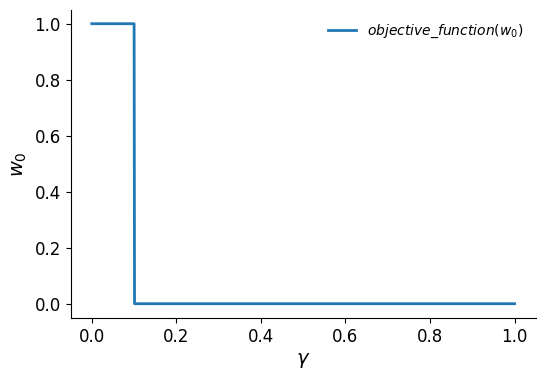

In [55]:
f0, f1, f2, f3 =0, 0.005, 0.01, 0.02  # pool fees
delta0, delta1, delta2, delta3 = 1, 0.99, 0.85, 0.75  # difficulty reduction
deltas = np.array([delta0, delta3])
fs = np.array([f0, f3])  # pool fees
lam ,b = 6, 3.125 # block discovery rate of the miner and reward for finding a block
c = lam * b / 1.1  # operational cost per time unit (profitability on average)
lams= lam / deltas # arrival rates of the pools
bs = b * (1 - fs) * deltas  # rewards after pool fees
# Initial reserves and time horizon
x, t = 0.5, 24
# Risk aversion parameter for the optimization
gam = 0.01

X_solo, X_pool = wealth_process(lam, b, c, 0, 1), wealth_process(lams[1], bs[1], c, 0, 1)
V1_solo, V2_solo = X_solo.E_Var_no_ruin(x, t)
print(f"Expected value when mining solo at time T={t}: {V1_solo}")
print(f"Standard deviation of the wealth process at time T={t}: {np.sqrt(V2_solo - V1_solo**2)}")
print(f"objective function value for solo mining: {V1_solo - gam * np.sqrt((V2_solo - V1_solo**2))}")
V1_pool, V2_pool = X_pool.E_Var_no_ruin(x, t)
print(f"Expected value when mining in pool at time T={t}: {V1_pool}")
print(f"Standard deviation of the wealth process at time T={t}: {np.sqrt(V2_pool - V1_pool**2)}")
print(f"objective function value for pool mining: {V1_pool - gam * np.sqrt((V2_pool - V1_pool**2))}")

w0 = 0.5  # Weight for solo mining
w = np.array([w0, 1-w0])  # equal weights for the two pools
n = len(w) - 1
X_mixed = wealth_process(lams, bs, c, n, w)
V1_mixed, V2_mixed = X_mixed.E_Var_no_ruin(x, t)
print(f"Expected value when mixing solo and pool mining at time T={t}: {V1_mixed}")
print(f"Standard deviation of the wealth process at time T={t}: {np.sqrt(V2_mixed - V1_mixed**2)}")
print(f"objective function value for mixed mining: {V1_mixed - gam * np.sqrt((V2_mixed - V1_mixed**2))}")

gams = np.linspace(0.0, 1, 1000)
opt_w0 = []
for gam in gams:
    print(f"Risk aversion parameter gamma: {gam}")
    def objective_function(w0):
        w = np.array([w0, 1-w0])
        X_mixed = wealth_process(lams, bs, c, n, w)
        V1, V2 = X_mixed.E_Var_no_ruin(x, t)
        return(-V1 + gam * (V2- V1**2)**0.5)

    res = sc.optimize.minimize_scalar(objective_function, bounds=(0, 1), method='bounded')
    best_position = {'position': np.array([res.x, 1-res.x]) , 'value': -res.fun}
    opt_w0.append(res.x)



plt.figure(figsize=(6, 4))
plt.plot(gams, opt_w0, linewidth=2, label=r'$objective\_function(w_0)$')
# plt.axvline(res.x, color='red', linestyle='--', linewidth=1.5, label=fr'optimum: $w_0={res.x:.3f}$')

plt.ylabel(r'$w_0$', fontsize=14)
plt.xlabel(r'$\gamma$', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(frameon=False)
sns.despine()
plt.show()


It looks like One only sticks to ine pool

In [76]:
f0, f1, f2, f3 =0, 0.005, 0.01, 0.02  # pool fees
delta0, delta1, delta2, delta3 = 1, 0.99, 0.85, 0.75  # difficulty reduction
deltas = np.array([delta0,delta1, delta2, delta3])
fs = np.array([f0, f1, f2, f3])  # pool fees
lam ,b = 6, 3.125 # block discovery rate of the miner and reward for finding a block
c = lam * b / 1.1  # operational cost per time unit (profitability on average)
lams= lam / deltas # arrival rates of the pools
bs = b * (1 - fs) * deltas  # rewards after pool fees
# Initial reserves and time horizon
x, t = 1, 1
# Risk aversion parameter for the optimization
gam = 0.05
n = 3
initial_cloud = []

for ik in itertools.product(range(2), repeat = n+1):
        if sum(ik) > 0:
            initial_cloud.append(np.array(ik)/ sum(ik))
bounds = [(0, 1)] * (n+1)
def constraint_sum_to_one(w):
        """Constraint function: ensure that the sum of components of w is equal to one."""
        return np.sum(w) - 1.0
def objective_function(w):
    X_mixed = wealth_process(lams, bs, c, n, w)
    V1, V2 = X_mixed.E_Var_no_ruin(x, t)
    return(-V1 + gam * (V2- V1**2)**0.5)

    # Define equality constraint: sum of components of w equals one
constraints = [{'type': 'eq', 'fun': constraint_sum_to_one}]
res_SLSP = []
for w_init in initial_cloud:
    res = sc.optimize.minimize(objective_function, w_init, bounds=bounds, constraints=constraints)
    res_SLSP.append({'position':res.x, 'value':-res.fun})
best_res = max(res_SLSP, key=lambda item: item['value'])
best_res

{'position': array([1.00000000e+00, 0.00000000e+00, 1.31838984e-15, 0.00000000e+00]),
 'value': np.float64(1.1713212076533879)}

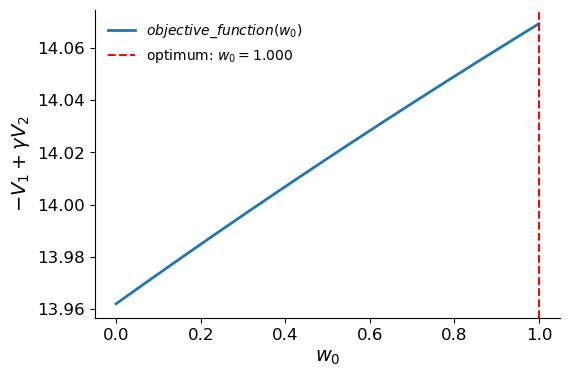

In [113]:
w0_grid = np.linspace(0, 1, 500)
obj_values = np.array([-objective_function(w0) for w0 in w0_grid])

plt.figure(figsize=(6, 4))
plt.plot(w0_grid, obj_values, linewidth=2, label=r'$objective\_function(w_0)$')
plt.axvline(res.x, color='red', linestyle='--', linewidth=1.5, label=fr'optimum: $w_0={res.x:.3f}$')

plt.xlabel(r'$w_0$', fontsize=14)
plt.ylabel(r'$-V_1 + \gamma V_2$', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(frameon=False)
sns.despine()
plt.show()

## Figure 3

        solo      Pool1      Pool2      Pool3  gamma
0  18.164062  18.081958  18.074364  16.519043   0.01
1  17.578125  17.507666  17.586229  16.163086   0.02
2  16.992188  16.933374  17.098093  15.807129   0.03
3  16.406250  16.359083  16.609957  15.451172   0.04
4  15.820312  15.784791  16.121821  15.095215   0.05


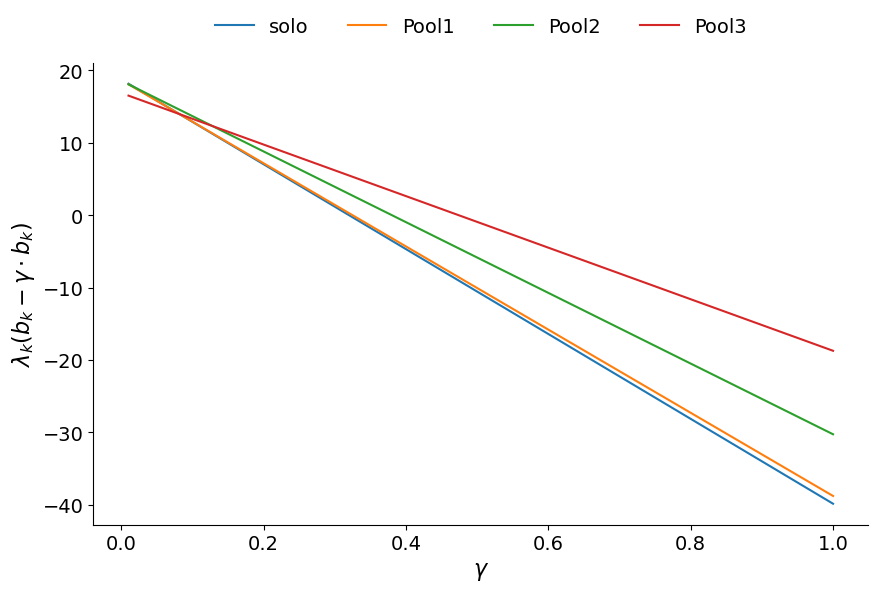

In [5]:
gams = np.linspace(0.01, 1, 100)
columns = ['solo'] + [f'Pool{k}' for k in range(1, len(bs))]
df = pd.DataFrame([lams * (bs - gam * (bs)**2) for gam in gams], columns=columns)
df['gamma'] = gams
print(df.head())
df.plot(x='gamma', y=columns, kind='line', title='', figsize=(10, 6))

plt.xlabel(r'$\gamma$')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r'$\gamma$', fontsize=16)
plt.ylabel(r'$\lambda_k(b_k - \gamma\cdot b_k)$', fontsize=16)

plt.legend(
    title='',
    fontsize=14,
    title_fontsize=16,
    loc='lower center',
    bbox_to_anchor=(0.5, 1.02),
    ncol=4,
    frameon=False
)
# 
# plt.legend(title='', fontsize=14, title_fontsize=16, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=4)

sns.despine()
plt.savefig('../figures/risk_aversion_mean_variance_tradeoff.pdf', format='pdf')
plt.show()


## Mean-Variance Efficient frontier

The mean-variance trade-off can follow from maximizing expected wealth 
$$
\sum_{k = 0}^n w_k \lambda^l_k b_k
$$
under variance constraints

$$
\sum_{k = 0}^n w_k \lambda^l_k b_k^2 = \sigma^2
$$

We have it explicitly for $n = 2$. Indeed,

$$
w_2 = 1 - w_1 - w_0\text{ } w_1 = \frac{\sigma^2 - \lambda_2 b_2^2 - w_0(\lambda_0 b_0^2 - \lambda_2 b_2^2)}{\lambda_1 b_{1}^2-\lambda_2 b_{2}^2}\text{, and }w_0 = \frac{\sigma^2 - \lambda_2 b_2^2}{\lambda_0 b_0^2 - \lambda_2 b_2^2}
$$

## Example 4

In [6]:
import pandas as pd
from itertools import permutations


# lam_l, c_l, x_l = lam_m[l], c_m[l], x_m[l]
# d_n, f_n = np.array([1, 0.9,0.6, 0.5, 0.1]), np.array([0, 0.01,0.3, 0.31, 0.5])

print(n)
# Generate weights for each pool
ws = np.arange(0.01, 1, 0.01)
if n >= 1:
    # Generate all possible combinations of weights for n+1 pools
    w_all_in_one_pool = []
    for perm in permutations(range(n), 2):
        for w in ws:
            weights = np.zeros(n)
            weights[perm[0]] = w
            weights[perm[1]] = 1 - w
            w_all_in_one_pool.append(weights)
    w_all_in_one_pool = np.array(w_all_in_one_pool)

    # Add a couple of Dirichlet distributed vectors with parameters all equal to one
    # dirichlet_vectors = np.random.dirichlet(np.ones(n + 1), size=100)
    # w_all_in_one_pool = np.vstack([w_all_in_one_pool, dirichlet_vectors])
w_all_in_one_pool


X0 = [wealth_process(lams, bs, c, n, w) for w in w_all_in_one_pool]

# # # # Create a DataFrame with the required columns
E_var_df = pd.DataFrame(
    [[X.E(0), X.Var()] + list(w) for X, w in zip(X0, w_all_in_one_pool)],
    columns=['E', 'Var'] + [f'w{i}' for i in range(n)]
)
E_var_df['pools'] = E_var_df[[f'w{i}' for i in range(n)]].apply(
    lambda row: ''.join([str(i) for i, w in enumerate(row) if w > 0]),
    axis=1
)
E_var_df


4


,E,Var,w0,w1,w2,w3,pools
0,4.234111,57.440830,0.01,0.99,0.00,0.00,01
1,4.235048,57.452476,0.02,0.98,0.00,0.00,01
2,4.235986,57.464122,0.03,0.97,0.00,0.00,01
3,4.236923,57.475767,0.04,0.96,0.00,0.00,01
4,4.237861,57.487413,0.05,0.95,0.00,0.00,01
...,...,...,...,...,...,...,...
1183,2.536298,36.256597,0.00,0.00,0.05,0.95,23
1184,2.519423,36.124418,0.00,0.00,0.04,0.96,23
1185,2.502548,35.992239,0.00,0.00,0.03,0.97,23
1186,2.485673,35.860061,0.00,0.00,0.02,0.98,23


The efficient frontier is formed by combination of two pools 

## Figure 4

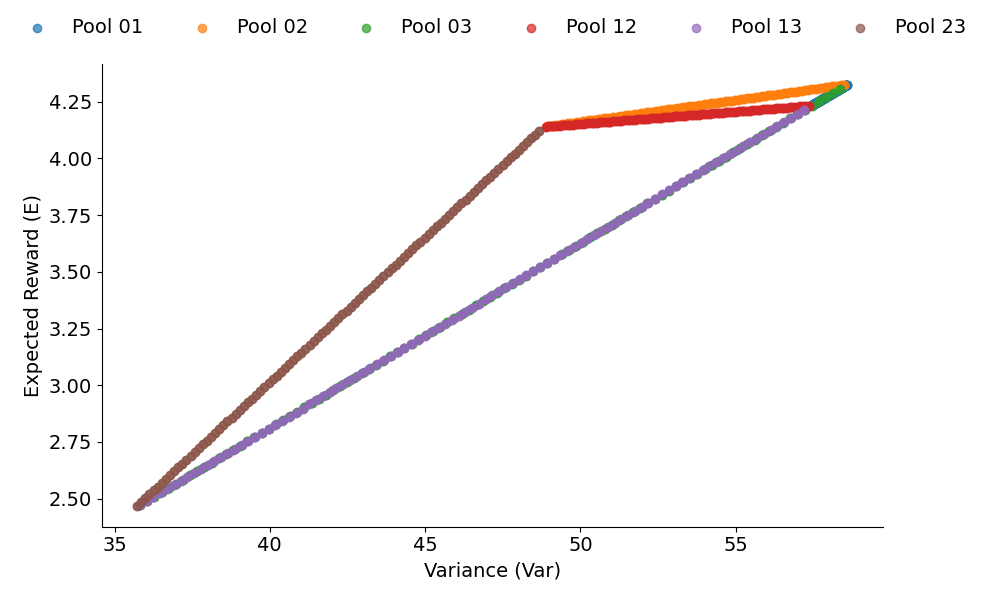

In [7]:
import matplotlib.pyplot as plt
plt.rcParams.update({'pdf.fonttype': 42, 'ps.fonttype': 42})  # Ensure text is embedded in the PDF
# Scatter plot
plt.figure(figsize=(10, 6))
for pool in E_var_df['pools'].unique():
    subset = E_var_df[E_var_df['pools'] == pool]
    plt.scatter(subset['Var'], subset['E'], label=f'Pool {pool}', alpha=0.7)
    # Add a vertical line to indicate the value of sig_2
# plt.axvline(x=sig_2, color='red', linestyle='--', label=f'sig_2 = {sig_2:.2f}')
# Labels and legend
plt.xlabel('Variance (Var)', fontsize=14)
plt.ylabel('Expected Reward (E)', fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(
    title='',
    fontsize=14,
    title_fontsize=16,
    loc='lower center',
    bbox_to_anchor=(0.5, 1.02),
    ncol=6,
    frameon=False
)# Ensure legend is properly configured
plt.tight_layout()  # Adjust layout to prevent clipping
sns.despine()
# Save the plot as a PDF file in the Figures folder
plt.savefig('../figures/efficient_frontier.pdf', format='pdf')

plt.show()  # Ensure plt.show() is called after all customizations
